# Точность границ Чебышёва и Чернова для суммы независимых двоичных величин

**Автор:** Дмитрий Багацкий  
**Дисциплина:** Теория информации  
**Раздел курса:** первая часть, лекции 1–5

## Связь с задачами курса

Работа развивает задачи 3.3–3.6 из указанного в задании сборника «Задачи ТИнф»: границу Чебышёва через дисперсию, её применение к среднему и двоичным величинам, а также границу Чернова. Файл задачника в репозитории отсутствует, поэтому дословные формулировки не воспроизводятся.

В исходных задачах выводятся вероятностные границы. Здесь исследуется их точность и информативность при конечном числе испытаний, а также сравнивается число испытаний, необходимое для достижения заданного уровня вероятности отклонения.

### Аннотация

Для суммы независимых величин Бернулли точная вероятность отклонения вычисляется по биномиальному распределению и сравнивается с границами Чебышёва и Чернова. Исследуется зависимость качества оценок от числа испытаний, параметра источника и величины отклонения. Отдельно рассматриваются асимметрия хвостов, области неинформативности и влияние дискретности. Практическая часть сравнивает первое точное пересечение уровня риска с достаточным числом испытаний по границам. Случайное моделирование не используется.

## 1. Постановка и исследовательские вопросы

Пусть $X_1,\ldots,X_n\sim\operatorname{Bernoulli}(p)$, $0<p<1$, независимы и одинаково распределены. Обозначим
$$
K_n=\sum_{i=1}^nX_i,\qquad \overline X_n=\frac{K_n}{n}.
$$
Исследуется
$$
P_{\mathrm{exact}}(n,p,\delta)=\mathsf P(|\overline X_n-p|\geq\delta).
$$

1. Насколько каждая граница завышает точную вероятность?
2. Как точность зависит от $n,p,\delta$?
3. Где границы неинформативны?
4. Как различаются хвосты при $p\neq0.5$?
5. Всегда ли исходная граница Чернова меньше границы Чебышёва?
6. Насколько консервативно оценивается необходимое число испытаний?
7. Как дискретность влияет на первое пересечение уровня риска?

## 2. Теоретические границы

Из $\mathsf E[X_i]=p$, $\operatorname{Var}(X_i)=p(1-p)$ следуют
$$
\mathsf E[\overline X_n]=p,\qquad \operatorname{Var}(\overline X_n)=\frac{p(1-p)}n.
$$
Неравенство Чебышёва даёт
$$
B_{\mathrm{Cheb,raw}}=\frac{p(1-p)}{n\delta^2},\qquad B_{\mathrm{Cheb}}=\min(1,B_{\mathrm{Cheb,raw}}).
$$
Исходное значение не меньше единицы не даёт нетривиального ограничения.

Так как $K_n\sim\operatorname{Bin}(n,p)$, для нестрогого события
$$
k_-=\lfloor n(p-\delta)\rfloor,\quad k_+=\lceil n(p+\delta)\rceil,
$$
$$
P_{\mathrm{exact}}=\mathsf P(K_n\leq k_-)+\mathsf P(K_n\geq k_+).
$$
Пороги вне носителя соответствуют невозможным хвостам. Числа около целых распознаются с допуском $10^{-12}$.

Для Чернова $\mathsf E[e^{tK_n}]=(1-p+pe^t)^n$. Применение неравенства Маркова и оптимизация по $t$ приводят к
$$
D_2(q\Vert p)=q\log_2\frac qp+(1-q)\log_2\frac{1-q}{1-p}.
$$
При $q>p$: $\mathsf P(\overline X_n\geq q)\leq2^{-nD_2(q\Vert p)}$; при $q<p$ аналогична нижняя оценка. Поэтому
$$
B_{\mathrm{Chernoff,raw}}=2^{-nD_2(p-\delta\Vert p)}+2^{-nD_2(p+\delta\Vert p)},
\quad B_{\mathrm{Chernoff}}=\min(1,B_{\mathrm{Chernoff,raw}}).
$$
Используются именно пороги $p\pm\delta$, а $2^{-nD_2}=e^{-nD_{\mathrm{nat}}}$.

In [1]:
import math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.special import logsumexp, xlogy
from scipy.stats import binom, norm
from IPython.display import display, Markdown

TOL=1e-12
LOG_TINY=math.log(np.finfo(float).tiny)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns",30)
pd.set_option("display.float_format",lambda x:f"{x:.6g}")

## 3. Реализация вычислений

Точные хвосты вычисляются через функции распределения и выживания, а также в логарифмическом масштабе. Верхний хвост не получается вычитанием из единицы: это сохраняет точность для редких событий. Если обычное представление обнуляется, логарифм вероятности остаётся доступным.

In [2]:
def validate_parameters(n:int,p:float,delta:float)->None:
    """Проверяет параметры биномиального эксперимента."""
    if not isinstance(n,(int,np.integer)) or n<1: raise ValueError("n должно быть положительным целым")
    if not 0<p<1: raise ValueError("p должно лежать в (0,1)")
    if not delta>0 or not math.isfinite(delta): raise ValueError("delta должно быть положительным")

def snap_near_integer(x:float,tol:float=TOL)->float:
    """Заменяет число ближайшим целым только в пределах tol."""
    nearest=round(x)
    return float(nearest) if abs(x-nearest)<=tol else float(x)

def integer_thresholds(n:int,p:float,delta:float)->tuple[int,int]:
    """Возвращает включённые пороги нижнего и верхнего хвостов."""
    validate_parameters(n,p,delta)
    return math.floor(snap_near_integer(n*(p-delta))),math.ceil(snap_near_integer(n*(p+delta)))

def bernoulli_divergence_bits(q:float,p:float)->float:
    """Вычисляет D_2(Ber(q)||Ber(p)) в битах."""
    if not 0<=q<=1 or not 0<p<1: raise ValueError("Нужны q в [0,1], p в (0,1)")
    return float((xlogy(q,q/p)+xlogy(1-q,(1-q)/(1-p)))/math.log(2))

def stable_log_lower(k:int,n:int,p:float)->float:
    """Устойчиво вычисляет log P(K<=k)."""
    value=float(binom.logcdf(k,n,p))
    return value if math.isfinite(value) else float(logsumexp(binom.logpmf(np.arange(k+1),n,p)))

def stable_log_upper(k:int,n:int,p:float)->float:
    """Устойчиво вычисляет log P(K>=k)."""
    value=float(binom.logsf(k-1,n,p))
    return value if math.isfinite(value) else float(logsumexp(binom.logpmf(np.arange(k,n+1),n,p)))

def exact_tails(n:int,p:float,delta:float)->dict[str,float]:
    """Возвращает точные хвосты и их натуральные логарифмы."""
    kl,kh=integer_thresholds(n,p,delta)
    if kl<0: lower,log_lower=0.0,-math.inf
    elif kl>=n: lower,log_lower=1.0,0.0
    else:
        log_lower=stable_log_lower(kl,n,p)
        lower=float(math.exp(log_lower)) if log_lower>LOG_TINY else 0.0
    if kh>n: upper,log_upper=0.0,-math.inf
    elif kh<=0: upper,log_upper=1.0,0.0
    else:
        log_upper=stable_log_upper(kh,n,p)
        upper=float(math.exp(log_upper)) if log_upper>LOG_TINY else 0.0
    log_total=float(logsumexp([log_lower,log_upper]))
    total=float(math.exp(log_total)) if log_total>LOG_TINY else 0.0
    return {"k_low":kl,"k_high":kh,"lower":lower,"upper":upper,"log_lower":log_lower,
            "log_upper":log_upper,"probability":min(1.0,total),"log_probability":min(0.0,log_total)}

def chebyshev_bound(n:int,p:float,delta:float)->dict[str,float]:
    """Возвращает исходную и ограниченную границы Чебышёва."""
    validate_parameters(n,p,delta);raw=p*(1-p)/(n*delta**2)
    return {"raw":raw,"bound":min(1.0,raw),"informative":raw<1}

def chernoff_tail_bound(n:int,p:float,q:float,side:str)->tuple[float,float]:
    """Возвращает границу хвоста Чернова и её логарифм."""
    if side=="lower":
        if q<0:return 0.0,-math.inf
        if q>=p:return 1.0,0.0
    elif side=="upper":
        if q>1:return 0.0,-math.inf
        if q<=p:return 1.0,0.0
    else: raise ValueError("side должен быть lower или upper")
    logb=-n*bernoulli_divergence_bits(q,p)*math.log(2)
    return (float(math.exp(logb)) if logb>LOG_TINY else 0.0),logb

def chernoff_bound(n:int,p:float,delta:float)->dict[str,float]:
    """Возвращает односторонние и двустороннюю границы Чернова."""
    validate_parameters(n,p,delta)
    lo,llo=chernoff_tail_bound(n,p,p-delta,"lower")
    up,lup=chernoff_tail_bound(n,p,p+delta,"upper")
    lraw=float(logsumexp([llo,lup]));raw=float(math.exp(lraw)) if lraw>LOG_TINY else 0.0
    return {"lower":lo,"upper":up,"log_lower":llo,"log_upper":lup,"raw":raw,
            "log_raw":lraw,"bound":min(1.0,raw),"informative":raw<1}

def comparison_metrics(n:int,p:float,delta:float)->dict[str,float]:
    """Объединяет вероятность, границы и метрики точности."""
    ex=exact_tails(n,p,delta);ch=chebyshev_bound(n,p,delta);cr=chernoff_bound(n,p,delta)
    def met(bound:float):
        lb=math.log(bound) if bound>0 else -math.inf
        diff=lb-ex["log_probability"]
        return bound-ex["probability"],math.exp(diff) if diff<709 else math.inf,diff/math.log(10)
    cag,car,cal=met(ch["bound"]);crg,crr,crl=met(cr["bound"])
    return {"n":n,"p":p,"delta":delta,**ex,"cheb_raw":ch["raw"],"cheb":ch["bound"],
            "cheb_info":ch["informative"],"chern_raw":cr["raw"],"chern":cr["bound"],
            "chern_info":cr["informative"],"cheb_abs_gap":cag,"cheb_ratio":car,
            "cheb_log_gap":cal,"chern_abs_gap":crg,"chern_ratio":crr,"chern_log_gap":crl}

## 4. Компактная проверка корректности

Проверки связаны с теорией и численной устойчивостью: симметрией Бернулли, перестановкой хвостов, неотрицательностью дивергенции, целочисленными порогами, прямым суммированием при малом $n$ и выполнением верхних границ.

In [3]:
assert integer_thresholds(10,.3,.1)==(2,4)
assert abs(bernoulli_divergence_bits(.3,.3))<TOL
assert all(bernoulli_divergence_bits(q,.3)>=-TOL for q in np.linspace(0,1,21))

a=exact_tails(100,.2,.05);b=exact_tails(100,.8,.05)
assert abs(a["probability"]-b["probability"])<1e-13
assert abs(a["lower"]-b["upper"])<1e-13 and abs(a["upper"]-b["lower"])<1e-13
s=exact_tails(100,.5,.1)
assert abs(s["lower"]-s["upper"])<1e-13

n,p,delta=12,.25,.1
e=exact_tails(n,p,delta);ks=np.arange(n+1);pmf=binom.pmf(ks,n,p)
direct=float(pmf[ks<=e["k_low"]].sum()+pmf[ks>=e["k_high"]].sum())
assert abs(direct-e["probability"])<1e-14

for p in [.1,.25,.5,.8]:
    for n in [20,100,500]:
        for r in [.1,.3,.7]:
            delta=r*min(p,1-p);z=comparison_metrics(n,p,delta)
            assert 0<=z["probability"]<=1
            assert z["cheb"]+1e-12>=z["probability"]
            assert z["chern"]+1e-12>=z["probability"]
print("Проверены пороги, симметрия, хвосты, дивергенция и обе верхние границы.")

Проверены пороги, симметрия, хвосты, дивергенция и обе верхние границы.


## 5. Зависимость от величины отклонения

Основной пример: $p=0.25$, $n=100$. По горизонтали используется нормированное отклонение $r=\delta/\min(p,1-p)$. В левой панели показаны вероятности, в правой — число десятичных порядков, на которое граница превосходит точное значение.

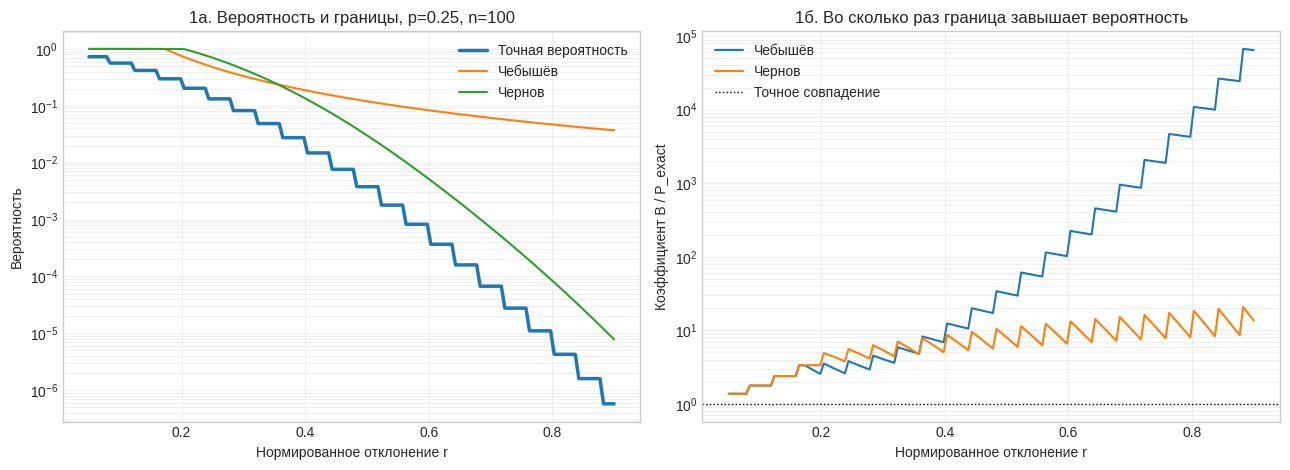

,p,n,delta,probability,cheb_raw,cheb,chern_raw,chern,cheb_ratio,chern_ratio,cheb_log_gap,chern_log_gap,cheb_info,chern_info
0,0.1,20,0.05,0.71482,1.8,1,1.4989,1,1.39895,1.39895,0.145803,0.145803,False,False
1,0.1,100,0.05,0.13015,0.36,0.36,0.48232,0.48232,2.76604,3.70588,0.441859,0.568892,True,True
2,0.25,100,0.05,0.298372,0.75,0.75,1.0237,1,2.51364,3.35152,0.400303,0.525242,True,False
3,0.25,500,0.05,0.011318,0.15,0.15,0.070898,0.070898,13.2527,6.26396,1.12231,0.796849,True,True
4,0.5,100,0.05,0.368202,1,1,1.21205,1,2.7159,2.7159,0.433914,0.433914,True,False
5,0.5,100,0.1,0.056888,0.25,0.25,0.267027,0.267027,4.39461,4.69392,0.64292,0.671536,True,True


In [4]:
p0,n0=.25,100
r_grid=np.linspace(.05,.9,150)
delta_data=pd.DataFrame([comparison_metrics(n0,p0,r*min(p0,1-p0))|{"r":r} for r in r_grid])

fig,ax=plt.subplots(1,2,figsize=(13,4.8))
ax[0].plot(delta_data.r,delta_data.probability,label="Точная вероятность",linewidth=2.5)
ax[0].plot(delta_data.r,delta_data.cheb,label="Чебышёв")
ax[0].plot(delta_data.r,delta_data.chern,label="Чернов")
ax[0].set_yscale("log")
ax[0].set(xlabel="Нормированное отклонение r",ylabel="Вероятность",
          title="1а. Вероятность и границы, p=0.25, n=100")

ax[1].plot(delta_data.r,delta_data.cheb_ratio,label="Чебышёв")
ax[1].plot(delta_data.r,delta_data.chern_ratio,label="Чернов")
ax[1].axhline(1,color="black",linestyle=":",linewidth=1,label="Точное совпадение")
ax[1].set_yscale("log")
ax[1].set(xlabel="Нормированное отклонение r",ylabel="Коэффициент B / P_exact",
          title="1б. Во сколько раз граница завышает вероятность")
for a in ax:
    a.legend();a.grid(True,which="both",alpha=.3)
plt.tight_layout();plt.show()

selected=[(.1,20,.05),(.1,100,.05),(.25,100,.05),(.25,500,.05),(.5,100,.05),(.5,100,.1)]
comparison_table=pd.DataFrame([comparison_metrics(n,p,d) for p,n,d in selected])
display(comparison_table[["p","n","delta","probability","cheb_raw","cheb","chern_raw","chern",
                          "cheb_ratio","chern_ratio","cheb_log_gap","chern_log_gap",
                          "cheb_info","chern_info"]].round(6))

Ступени точной кривой возникают при переходе порога через целое значение $K_n$. Ограниченные границы сначала равны единице и становятся информативными при достаточно большом отклонении. На графике 1б значение 1 означает точное совпадение, 10 — завышение в 10 раз, 100 — в 100 раз; логарифмическая шкала позволяет одновременно видеть разные порядки величин.

## 6. Зависимость от числа испытаний

Используется общее абсолютное отклонение $\delta=0.05$. Три значения $p$ показаны отдельными фигурами, чтобы ступени точной вероятности и различие границ не терялись в мелких панелях.

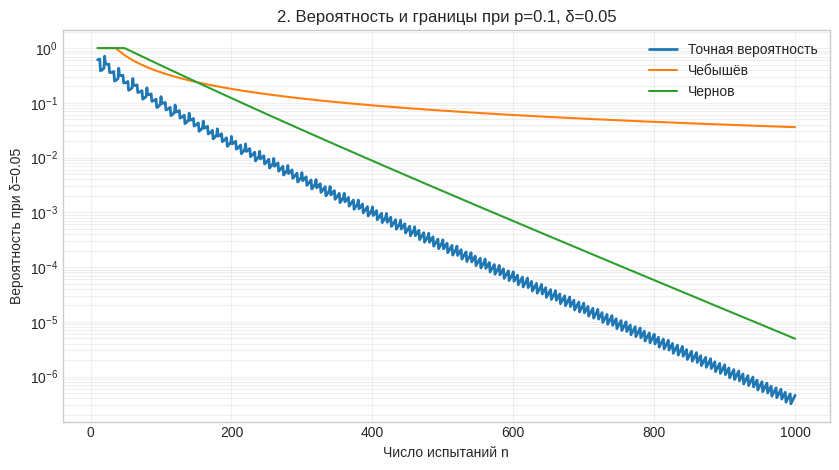

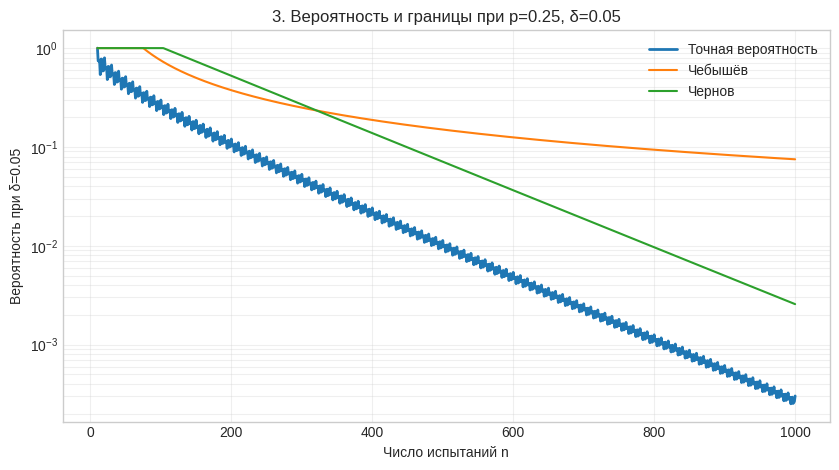

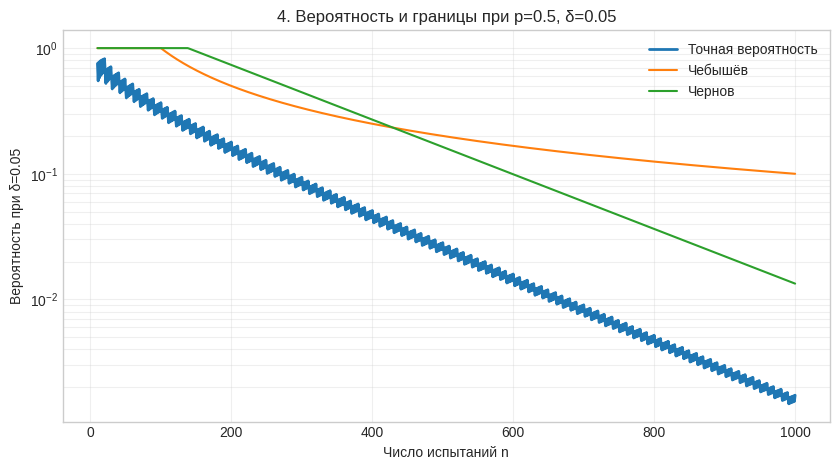

In [5]:
n_grid=np.arange(10,1001)
n_data=[]
for number,p in enumerate([.1,.25,.5],start=2):
    d=pd.DataFrame([comparison_metrics(int(n),p,.05) for n in n_grid])
    d["source_p"]=p;n_data.append(d)
    plt.figure(figsize=(8.5,4.8))
    plt.plot(d.n,d.probability,label="Точная вероятность",linewidth=2)
    plt.plot(d.n,d.cheb,label="Чебышёв")
    plt.plot(d.n,d.chern,label="Чернов")
    plt.yscale("log");plt.xlabel("Число испытаний n");plt.ylabel("Вероятность при δ=0.05")
    plt.title(f"{number}. Вероятность и границы при p={p}, δ=0.05")
    plt.legend();plt.grid(True,which="both",alpha=.3);plt.tight_layout();plt.show()
n_data=pd.concat(n_data,ignore_index=True)

Во всех трёх случаях наблюдается общий спад с ростом $n$, но точная вероятность локально колеблется при изменении целочисленных порогов. Чебышёв убывает как $1/n$, тогда как точный хвост и граница Чернова имеют преимущественно экспоненциальный масштаб. Отдельные фигуры позволяют сравнить форму ступеней для разных $p$.

## 7. Асимметрия хвостов

Для $p=0.1$, $n=100$ сравниваются точные хвосты и соответствующие односторонние границы Чернова. Используется нормированное отклонение $r$, чтобы оба порога оставались внутри $[0,1]$.

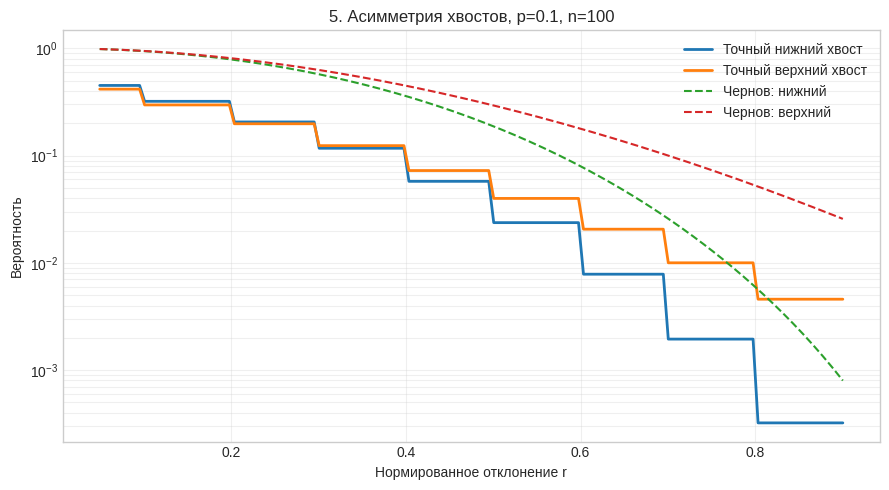

In [6]:
p_tail,n_tail=.1,100
tail_rows=[]
for r in np.linspace(.05,.9,150):
    delta=r*min(p_tail,1-p_tail);ex=exact_tails(n_tail,p_tail,delta);cr=chernoff_bound(n_tail,p_tail,delta)
    tail_rows.append({"r":r,"lower":ex["lower"],"upper":ex["upper"],
                      "chern_lower":cr["lower"],"chern_upper":cr["upper"]})
tails=pd.DataFrame(tail_rows)
plt.figure(figsize=(9,5))
plt.plot(tails.r,tails.lower,label="Точный нижний хвост",linewidth=2)
plt.plot(tails.r,tails.upper,label="Точный верхний хвост",linewidth=2)
plt.plot(tails.r,tails.chern_lower,"--",label="Чернов: нижний")
plt.plot(tails.r,tails.chern_upper,"--",label="Чернов: верхний")
plt.yscale("log");plt.xlabel("Нормированное отклонение r");plt.ylabel("Вероятность")
plt.title("5. Асимметрия хвостов, p=0.1, n=100")
plt.legend();plt.grid(True,which="both",alpha=.3);plt.tight_layout();plt.show()

При $p\neq0.5$ одинаковые отклонения в разные стороны соответствуют разным значениям дивергенции и разным биномиальным хвостам. При замене $p$ на $1-p$ хвосты меняются местами, что подтверждено в проверках.

## 8. Карты завышения и информативности границ

Одна точка каждой карты соответствует паре $(p,r)$ при фиксированном $n=100$, где $r=\delta/\min(p,1-p)$. Карты 6а и 6б показывают
$$
\log_{10}\frac{B}{P_{\mathrm{exact}}}.
$$
Значения 0, 1, 2 и 3 означают соответственно совпадение, завышение примерно в 10, 100 и 1000 раз. Карта 6в сравнивает исходные, не ограниченные единицей границы: серый цвет означает, что обе неинформативны; синий — меньше Чебышёв; оранжевый — меньше Чернов.

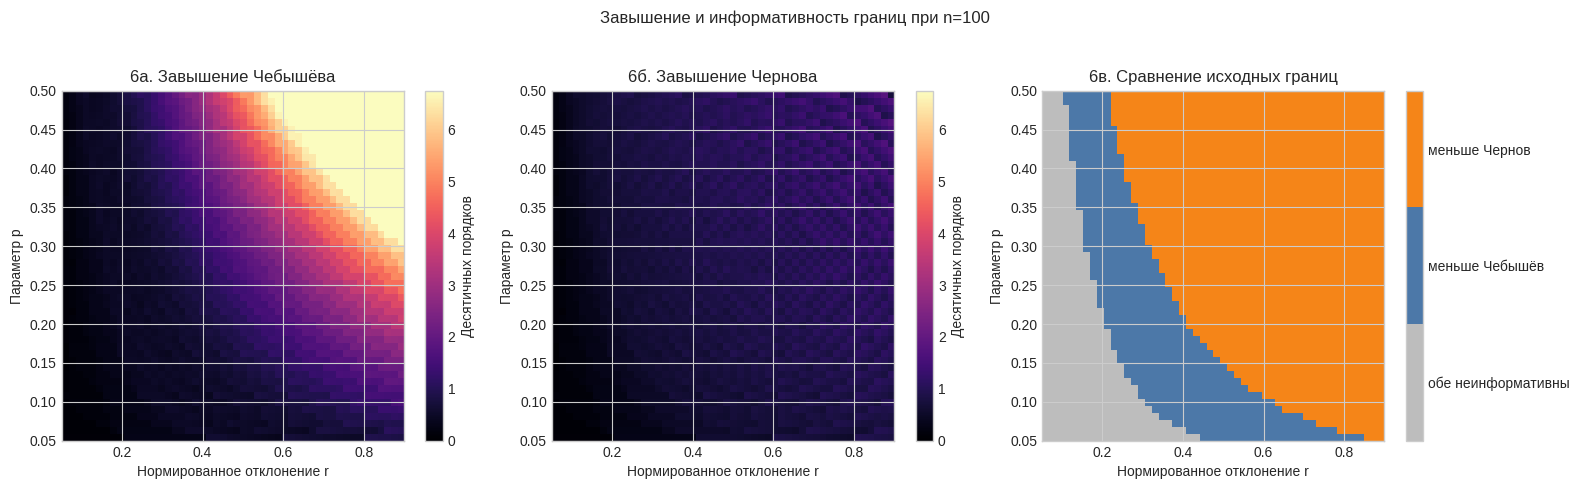

In [7]:
p_map=np.linspace(.05,.5,50);r_map=np.linspace(.05,.9,50)
gap_cheb=np.empty((len(p_map),len(r_map)));gap_chern=np.empty_like(gap_cheb);winner=np.empty_like(gap_cheb,dtype=int)
for i,p in enumerate(p_map):
    for j,r in enumerate(r_map):
        z=comparison_metrics(100,p,r*min(p,1-p))
        gap_cheb[i,j]=z["cheb_log_gap"];gap_chern[i,j]=z["chern_log_gap"]
        if not z["cheb_info"] and not z["chern_info"]:winner[i,j]=0
        elif z["cheb_raw"]<=z["chern_raw"]:winner[i,j]=1
        else:winner[i,j]=2

fig,axes=plt.subplots(1,3,figsize=(16,4.7))
extent=[r_map.min(),r_map.max(),p_map.min(),p_map.max()]
vmax=float(np.nanpercentile(np.r_[gap_cheb.ravel(),gap_chern.ravel()],95))
im0=axes[0].imshow(gap_cheb,origin="lower",aspect="auto",extent=extent,cmap="magma",vmin=0,vmax=vmax)
im1=axes[1].imshow(gap_chern,origin="lower",aspect="auto",extent=extent,cmap="magma",vmin=0,vmax=vmax)
fig.colorbar(im0,ax=axes[0],label="Десятичных порядков");fig.colorbar(im1,ax=axes[1],label="Десятичных порядков")
cmap=ListedColormap(["#bdbdbd","#4c78a8","#f58518"])
im2=axes[2].imshow(winner,origin="lower",aspect="auto",extent=extent,cmap=cmap,vmin=-.5,vmax=2.5)
cb=fig.colorbar(im2,ax=axes[2],ticks=[0,1,2]);cb.ax.set_yticklabels(["обе неинформативны","меньше Чебышёв","меньше Чернов"])
axes[0].set_title("6а. Завышение Чебышёва");axes[1].set_title("6б. Завышение Чернова");axes[2].set_title("6в. Сравнение исходных границ")
for ax in axes:ax.set_xlabel("Нормированное отклонение r");ax.set_ylabel("Параметр p")
fig.suptitle("Завышение и информативность границ при n=100",y=1.03);plt.tight_layout();plt.show()

Первые две карты показывают степень консервативности, а не статистическую ошибку оценки. На третьей карте сравниваются исходные границы, поскольку после ограничения единицей различие в неинформативной области исчезает. Карты позволяют одновременно увидеть влияние формы источника $p$ и относительного размера отклонения $r$.

## 9. Необходимое число испытаний

Для риска $\alpha$ граница Чебышёва даёт
$$
n_{\mathrm{Cheb}}=\left\lceil\frac{p(1-p)}{\alpha\delta^2}\right\rceil.
$$
Для Чернова минимальное достаточное $n$ находится двоичным поиском, поскольку аналитическая граница монотонна. Точная вероятность по $n$ немонотонна, поэтому первое пересечение ищется последовательным перебором.

In [8]:
def chebyshev_required_n(p:float,delta:float,alpha:float)->int:
    """Минимальное достаточное n по Чебышёву."""
    x=snap_near_integer(p*(1-p)/(alpha*delta**2))
    return max(1,math.ceil(x))

def chernoff_required_n(p:float,delta:float,alpha:float)->int:
    """Минимальное достаточное n по двусторонней границе Чернова."""
    def ok(n:int)->bool:return chernoff_bound(n,p,delta)["log_raw"]<=math.log(alpha)
    hi=1
    while not ok(hi):hi*=2
    lo=1
    while lo<hi:
        mid=(lo+hi)//2
        if ok(mid):hi=mid
        else:lo=mid+1
    return lo

def first_exact_crossing(p:float,delta:float,alpha:float,n_max:int=200_000)->int|None:
    """Последовательно ищет первое n с P_exact <= alpha."""
    log_alpha=math.log(alpha)
    for n in range(1,n_max+1):
        if exact_tails(n,p,delta)["log_probability"]<=log_alpha:return n
    return None

cases=[(.1,.05),(.25,.05),(.5,.05),(.25,.1)]
alphas=[.05,.01,.001]
sample_rows=[];search_start=time.perf_counter()
for p,delta in cases:
    for alpha in alphas:
        nf=first_exact_crossing(p,delta,alpha)
        nc=chebyshev_required_n(p,delta,alpha);nh=chernoff_required_n(p,delta,alpha)
        sample_rows.append({"p":p,"delta":delta,"alpha":alpha,"n_first":nf,"n_Cheb":nc,"n_Chernoff":nh,
                            "C_Cheb":nc/nf if nf else np.nan,"C_Chernoff":nh/nf if nf else np.nan})
sample_sizes=pd.DataFrame(sample_rows);search_seconds=time.perf_counter()-search_start

for _,row in sample_sizes.iterrows():
    p,delta,alpha=row.p,row.delta,row.alpha
    nc,nh,nf=int(row.n_Cheb),int(row.n_Chernoff),int(row.n_first)
    assert chebyshev_bound(nc,p,delta)["raw"]<=alpha*(1+1e-12)
    if nc>1:assert chebyshev_bound(nc-1,p,delta)["raw"]>alpha*(1-1e-12)
    assert chernoff_bound(nh,p,delta)["log_raw"]<=math.log(alpha)+1e-12
    if nh>1:assert chernoff_bound(nh-1,p,delta)["log_raw"]>math.log(alpha)-1e-12
    assert exact_tails(nf,p,delta)["log_probability"]<=math.log(alpha)+1e-12
    assert all(exact_tails(n,p,delta)["log_probability"]>math.log(alpha)-1e-12 for n in range(1,nf))

display(sample_sizes.round(3))
print(f"Поиск первых пересечений: {search_seconds:.2f} с")

,p,delta,alpha,n_first,n_Cheb,n_Chernoff,C_Cheb,C_Chernoff
0,0.1,0.05,0.05,134,720,267,5.373,1.993
1,0.1,0.05,0.01,234,3600,390,15.385,1.667
2,0.1,0.05,0.001,387,36000,571,93.023,1.475
3,0.25,0.05,0.05,284,1500,553,5.282,1.947
4,0.25,0.05,0.01,494,7500,795,15.182,1.609
5,0.25,0.05,0.001,804,75000,1143,93.284,1.422
6,0.5,0.05,0.05,371,2000,737,5.391,1.987
7,0.5,0.05,0.01,651,10000,1058,15.361,1.625
8,0.5,0.05,0.001,1071,100000,1518,93.371,1.417
9,0.25,0.1,0.05,66,375,138,5.682,2.091


Поиск первых пересечений: 2.45 с


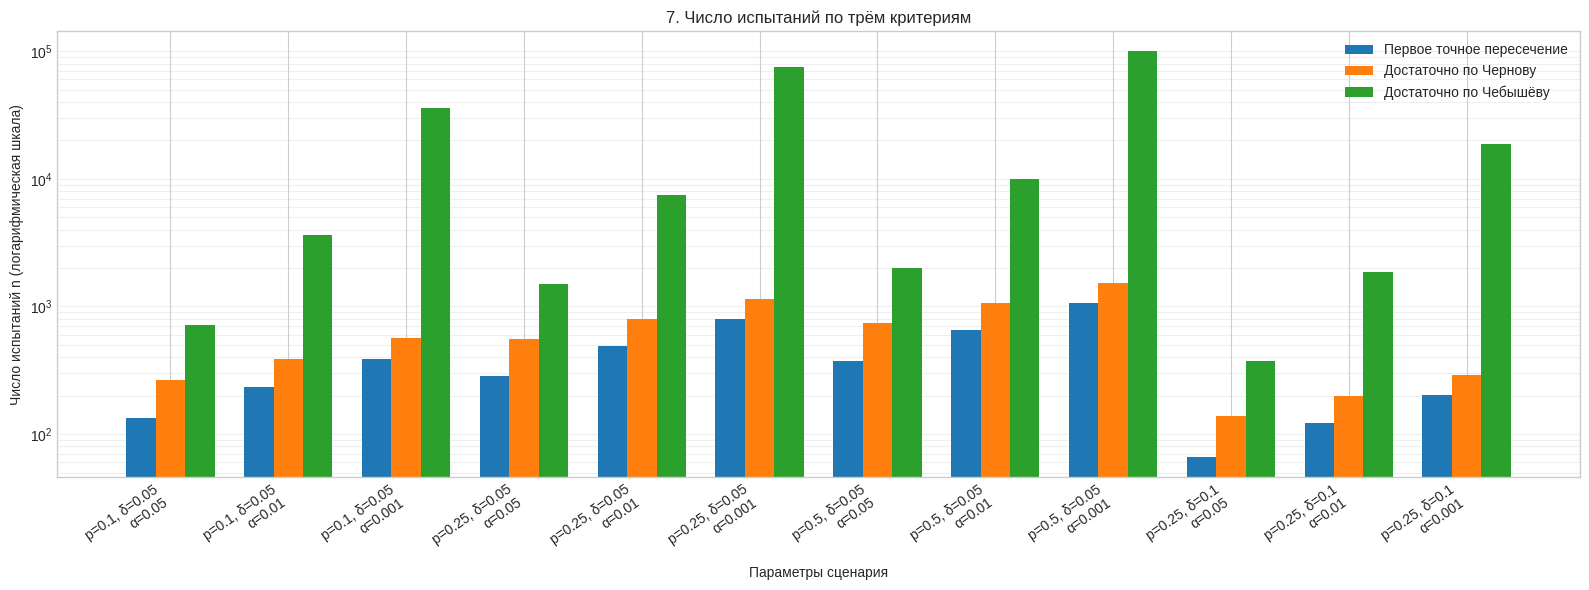

In [9]:
labels=[f"p={r.p:g}, δ={r.delta:g}\nα={r.alpha:g}" for _,r in sample_sizes.iterrows()]
x=np.arange(len(sample_sizes));w=.25
fig,ax=plt.subplots(figsize=(16,6))
ax.bar(x-w,sample_sizes.n_first,w,label="Первое точное пересечение")
ax.bar(x,sample_sizes.n_Chernoff,w,label="Достаточно по Чернову")
ax.bar(x+w,sample_sizes.n_Cheb,w,label="Достаточно по Чебышёву")
ax.set_yscale("log");ax.set_xticks(x,labels,rotation=35,ha="right")
ax.set_ylabel("Число испытаний n (логарифмическая шкала)")
ax.set_xlabel("Параметры сценария")
ax.set_title("7. Число испытаний по трём критериям")
ax.legend();ax.grid(True,axis="y",which="both",alpha=.3);plt.tight_layout();plt.show()

Каждая группа столбцов соответствует сценарию $(p,\delta,\alpha)$. Синий столбец показывает первое точное пересечение, оранжевый — достаточное $n$ по Чернову, зелёный — по Чебышёву. Логарифмическая шкала позволяет сопоставлять значения, различающиеся на порядки. Первое пересечение не является устойчивой гарантией, тогда как аналитические границы сохраняют условие при дальнейшем росте $n$.

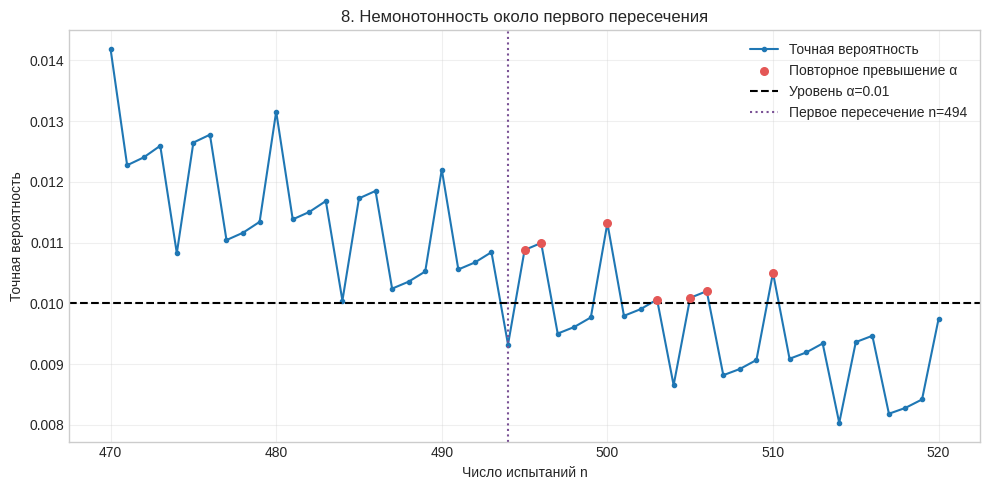

In [10]:
example=sample_sizes[(sample_sizes.p==.25)&(sample_sizes.delta==.05)&(sample_sizes.alpha==.01)].iloc[0]
nf=int(example.n_first)
window=np.arange(470,521)
local=np.array([exact_tails(int(n),.25,.05)["probability"] for n in window])
repeated=(window>nf)&(local>.01)

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(window,local,marker="o",markersize=3,linewidth=1.5,label="Точная вероятность")
ax.scatter(window[repeated],local[repeated],color="#e45756",s=30,zorder=4,label="Повторное превышение α")
ax.axhline(.01,color="black",linestyle="--",label="Уровень α=0.01")
ax.axvline(nf,color="#7a5195",linestyle=":",label=f"Первое пересечение n={nf}")
ax.set_xlabel("Число испытаний n");ax.set_ylabel("Точная вероятность")
ax.set_title("8. Немонотонность около первого пересечения")
ax.legend();ax.grid(True,alpha=.3)
plt.tight_layout();plt.show()

На участке $n=470,\ldots,520$ видно, что точная вероятность не убывает при каждом увеличении числа испытаний. Красные точки отмечают значения после первого пересечения, снова превысившие уровень $\alpha=0.01$. Скачки связаны с целочисленным изменением границ события при увеличении $n$.

## 10. Контрольный нормальный пример

Пусть $Z\sim\mathcal N(0,1)$. Из $\mathsf E[e^{tZ}]=e^{t^2/2}$ и неравенства Маркова
$$
\mathsf P(Z\geq a)\leq \exp(-ta+t^2/2).
$$
Минимум по $t\geq0$ достигается при $t=a$, поэтому
$$
\mathsf P(Z\geq a)\leq e^{-a^2/2}.
$$

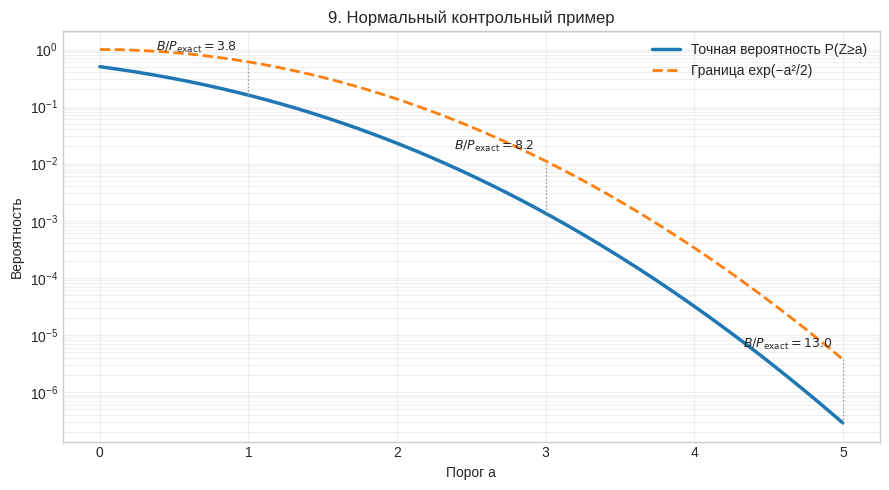

In [11]:
a_grid=np.linspace(0,5,250)
normal_exact=norm.sf(a_grid);normal_bound=np.exp(-a_grid**2/2)
plt.figure(figsize=(9,5))
plt.plot(a_grid,normal_exact,label="Точная вероятность P(Z≥a)",linewidth=2.5)
plt.plot(a_grid,normal_bound,"--",label="Граница exp(−a²/2)",linewidth=2)
for a in [1,3,5]:
    exact=float(norm.sf(a));bound=float(math.exp(-a*a/2));ratio=bound/exact
    plt.vlines(a,exact,bound,color="0.6",linestyle=":",linewidth=1)
    plt.annotate(fr"$B/P_{{\mathrm{{exact}}}}={ratio:.1f}$",(a,bound),
                 xytext=(-8,8),textcoords="offset points",ha="right",fontsize=9)
plt.yscale("log");plt.xlabel("Порог a");plt.ylabel("Вероятность")
plt.title("9. Нормальный контрольный пример")
plt.legend();plt.grid(True,which="both",alpha=.3);plt.tight_layout();plt.show()

Вертикальные отрезки соединяют точный хвост с его верхней границей. Подпись $B/P_{\mathrm{exact}}$ означает, во сколько раз граница $e^{-a^2/2}$ превышает точную вероятность $\mathsf P(Z\geq a)$. При $a=1,3,5$ этот коэффициент растёт: граница сохраняет экспоненциальный масштаб, но не учитывает предэкспоненциальный множитель.

## 11. Ограничения

Рассматриваются независимые одинаково распределённые испытания Бернулли с известным $p$. Выводы относятся к конечным сеткам параметров. Точные биномиальные вероятности вычисляются численно; для редких событий используется логарифмическое представление, но оно также ограничено возможностями библиотеки и машинной арифметики. Первое пересечение уровня риска не является устойчивой гарантией. Чебышёв и Чернов — аналитические верхние оценки, а не статистические оценки по данным. Случайное моделирование не проводится.

## 12. Ответы на исследовательские вопросы и заключение

Следующая ячейка формирует численные ответы из рассчитанных таблиц и сеток.

In [12]:
map_total=winner.size
both_noninfo=int(np.sum(winner==0));cheb_smaller=int(np.sum(winner==1));chern_smaller=int(np.sum(winner==2))
r_mid=.5;d_mid=r_mid*min(p_tail,1-p_tail)
tail_mid=exact_tails(n_tail,p_tail,d_mid)
tail_ratio=max(tail_mid["lower"],tail_mid["upper"])/min(tail_mid["lower"],tail_mid["upper"])
max_cheb_C=float(sample_sizes.C_Cheb.max());max_chern_C=float(sample_sizes.C_Chernoff.max())
rebound=bool(np.any(local[window>nf]>.01))
normal_ratio=float((normal_bound/normal_exact)[-1])

conclusion=fr"""1. **Завышение границ.** В основной таблице максимальные коэффициенты завышения равны
{comparison_table.cheb_ratio.max():.2f} для Чебышёва и {comparison_table.chern_ratio.max():.2f} для Чернова.
Логарифмический разрыв остаётся основной устойчивой метрикой для редких событий.

2. **Зависимость от параметров.** С ростом \(n\) и \(\delta\) точная вероятность имеет общий нисходящий тренд,
но может локально возрастать из-за дискретности. Чебышёв убывает как \(1/n\), тогда как граница Чернова отражает экспоненциальный масштаб. Параметр \(p\) влияет через дисперсию
и несимметричность биномиального распределения.

3. **Неинформативность.** На карте обе исходные границы неинформативны в {both_noninfo} из {map_total} точек
({100*both_noninfo/map_total:.1f}%). Ограничение единицей корректно, но скрывает различие исходных оценок.

4. **Асимметрия хвостов.** При \(p=0.1,n=100,r=0.5\) отношение большего точного хвоста к меньшему равно
{tail_ratio:.2f}. При замене \(p\) на \(1-p\) хвосты меняются местами.

5. **Сравнение исходных границ.** В информативной части карты Чебышёв меньше в {cheb_smaller} точках,
Чернов — в {chern_smaller}. Поэтому утверждение «Чернов всегда меньше» {'не подтверждается' if cheb_smaller else 'подтверждается на исследованной сетке'}.

6. **Число испытаний.** На выбранных сценариях максимальный коэффициент консервативности равен
{max_cheb_C:.2f} для Чебышёва и {max_chern_C:.2f} для Чернова относительно первого точного пересечения.
Это сравнение достаточной гарантии с первым пересечением, а не с устойчивым порогом.

7. **Дискретность.** После первого пересечения в показанном окне вероятность
{'снова поднимается выше уровня' if rebound else 'не поднимается выше уровня, хотя локальные скачки сохраняются'}.
Причина немонотонности — целочисленные изменения \(k_-\) и \(k_+\).

Контрольный нормальный пример также показывает консервативность: при \(a=5\) граница превышает точный хвост
примерно в {normal_ratio:.1f} раза. Работа воспроизводит известные вероятностные оценки и количественно исследует
их точность; полученные результаты не являются новыми неравенствами."""
display(Markdown(conclusion))

1. **Завышение границ.** В основной таблице максимальные коэффициенты завышения равны
13.25 для Чебышёва и 6.26 для Чернова.
Логарифмический разрыв остаётся основной устойчивой метрикой для редких событий.

2. **Зависимость от параметров.** С ростом \(n\) и \(\delta\) точная вероятность имеет общий нисходящий тренд,
но может локально возрастать из-за дискретности. Чебышёв убывает как \(1/n\), тогда как граница Чернова отражает экспоненциальный масштаб. Параметр \(p\) влияет через дисперсию
и несимметричность биномиального распределения.

3. **Неинформативность.** На карте обе исходные границы неинформативны в 424 из 2500 точек
(17.0%). Ограничение единицей корректно, но скрывает различие исходных оценок.

4. **Асимметрия хвостов.** При \(p=0.1,n=100,r=0.5\) отношение большего точного хвоста к меньшему равно
1.26. При замене \(p\) на \(1-p\) хвосты меняются местами.

5. **Сравнение исходных границ.** В информативной части карты Чебышёв меньше в 569 точках,
Чернов — в 1507. Поэтому утверждение «Чернов всегда меньше» не подтверждается.

6. **Число испытаний.** На выбранных сценариях максимальный коэффициент консервативности равен
93.37 для Чебышёва и 2.09 для Чернова относительно первого точного пересечения.
Это сравнение достаточной гарантии с первым пересечением, а не с устойчивым порогом.

7. **Дискретность.** После первого пересечения в показанном окне вероятность
снова поднимается выше уровня.
Причина немонотонности — целочисленные изменения \(k_-\) и \(k_+\).

Контрольный нормальный пример также показывает консервативность: при \(a=5\) граница превышает точный хвост
примерно в 13.0 раза. Работа воспроизводит известные вероятностные оценки и количественно исследует
их точность; полученные результаты не являются новыми неравенствами.